In [ ]:
# repo root + config (walk parents; do not use ../..)
from pathlib import Path
import json
import yaml

def _repo_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        if (p / "config" / "config.yaml").is_file():
            return p
    raise FileNotFoundError("config/config.yaml not found walking from " + str(start))

PROJECT_ROOT = _repo_root()
CFG_YAML = yaml.safe_load((PROJECT_ROOT / "config" / "config.yaml").read_text(encoding="utf-8"))
_cfg_json = PROJECT_ROOT / "config" / "config.json"
if _cfg_json.is_file():
    with open(_cfg_json, encoding="utf-8") as _f:
        CFG = json.load(_f)



# RQ1: Linguistic predictors of normalised semantic entropy

**Clean analysis notebook** (does not regenerate perturbations or re-run models).

Models normalised semantic entropy as a function of linguistic / perturbation features
on two datasets:

| Dataset | Label | Entropy file | Entropy column |
|---|---|---|---|
| CADEC | patient-generated health text | `outputs/rq3/entropy_cadec.csv` | `normalised_entropy` |
| MedMentions | biomedical literature | `outputs/rq1/entropy_full_umls.csv` | `normalised_semantic_entropy_full` |

**Why not OLS:** entropy is zero-inflated (~50–75% exact zeros) and bounded in \([0,1]\).
We use a **two-part hurdle** model:

1. **Binary part:** logistic regression for \(P(\hat H > 0)\)
2. **Magnitude part:** among nonzero cases, Beta regression on \(\hat H\) (fallback: OLS on
   logit-transformed \(\hat H\) if Beta fails)

Random intercepts for `model_name` and `instance_id` are attempted; if the mixed model
does not converge we report **fixed effects + cluster-robust SEs** (cluster = `instance_id`)
and state that clearly.

Outputs per dataset under `outputs/rq1/` (MedMentions) and `outputs/rq3/` (CADEC).

In [1]:
# Setup
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = PROJECT_ROOT
assert (PROJECT_ROOT / "config" / "config.json").is_file()

DATASETS = {
    "MedMentions": {
        "label": "MedMentions (biomedical literature)",
        "entropy_path": PROJECT_ROOT / "outputs" / "rq1" / "entropy_full_umls.csv",
        "entropy_col": "normalised_entropy_dedup",
        "entropy_col_raw": "normalised_semantic_entropy_full",  # labelled sensitivity
        "retained_col": "retained_m_distinct",
        "out_dir": PROJECT_ROOT / "outputs" / "rq1",
        "fig_dir": PROJECT_ROOT / "outputs" / "rq1" / "figures",
    },
    "CADEC": {
        "label": "CADEC (patient-generated health text)",
        "entropy_path": PROJECT_ROOT / "outputs" / "rq3" / "entropy_cadec.csv",
        "entropy_col": "normalised_entropy_dedup",
        "entropy_col_raw": "normalised_entropy",  # labelled sensitivity
        "retained_col": "retained_m_distinct",
        "out_dir": PROJECT_ROOT / "outputs" / "rq3",
        "fig_dir": PROJECT_ROOT / "outputs" / "rq3" / "figures",
    },
}

# Feature sources
MM_LING = PROJECT_ROOT / "outputs" / "rq1" / "intermediate" / "rq1_linguistic_features.csv"
MM_MO = PROJECT_ROOT / "outputs" / "rq1" / "intermediate" / "rq1_model_outputs.csv"
CADEC_PERT = PROJECT_ROOT / "outputs" / "rq3" / "intermediate" / "rq3_cadec_perturbations.csv"
CADEC_VAL = PROJECT_ROOT / "outputs" / "rq3" / "intermediate" / "rq3_cadec_validated_perturbations_full.csv"

ALPHA = 0.05
RNG = np.random.default_rng(42)


# Optional dataset restriction, default all. MedMentions ANALYSIS must not be produced before
# the 21 September cutoff, and its entropy file is still pre-rule-1-fix, so an unrestricted run
# would write MedMentions outputs computed on contaminated predicted_cui.
import os as _os
_only = _os.environ.get("RQ_DATASETS", "").strip()
if _only:
    _keep = {d.strip() for d in _only.split(",") if d.strip()}
    _dropped = sorted(set(DATASETS) - _keep)
    DATASETS = {k: v for k, v in DATASETS.items() if k in _keep}
    print(f"RQ_DATASETS={_only!r} -> running {sorted(DATASETS)}; skipped {_dropped}")
    assert DATASETS, f"RQ_DATASETS={_only!r} matched no dataset"

# --- SENSITIVITY ARM SWITCH -------------------------------------------------------------
# RQ_ENTROPY_ARM=raw runs the ALL-ACCEPTED-VARIANTS arm: normalised entropy over m_accepted,
# rows filtered by retained_m_accepted. Default "dedup" is the PRIMARY arm
# (docs/ANALYSIS_PRECOMMIT.md section 3). Both columns are emitted in the same pass by the
# entropy producers, so this is a column swap and a row-filter swap, never a re-run.
# Outputs are suffixed under the raw arm so the primary artefacts are never overwritten.
_ARM = _os.environ.get("RQ_ENTROPY_ARM", "dedup").strip().lower()
assert _ARM in ("dedup", "raw"), f"RQ_ENTROPY_ARM must be dedup|raw, got {_ARM!r}"
ARM_SUFFIX = "" if _ARM == "dedup" else "_rawm"
if _ARM == "raw":
    for _k, _cfg in DATASETS.items():
        _cfg["entropy_col"] = _cfg["entropy_col_raw"]
        _cfg["retained_col"] = "retained_m_accepted"
        _cfg["label"] = _cfg["label"] + " [raw-m sensitivity arm]"
    print("*** SENSITIVITY ARM: raw m_accepted — entropy_col ->",
          {k: v["entropy_col"] for k, v in DATASETS.items()},
          "| retained_col -> retained_m_accepted ***")
else:
    print(f"Primary arm: {[(k, v['entropy_col']) for k, v in DATASETS.items()]}")


for ds, cfg in DATASETS.items():
    cfg["out_dir"].mkdir(parents=True, exist_ok=True)
    cfg["fig_dir"].mkdir(parents=True, exist_ok=True)
    assert cfg["entropy_path"].is_file(), f"Missing {cfg['entropy_path']}"
    print(f"OK {ds}: {cfg['entropy_path'].name}")
print(f"MM linguistic features: {MM_LING.is_file()}")
print(f"CADEC perts: {CADEC_PERT.is_file()} | validated: {CADEC_VAL.is_file()}")

def _apply_retained_filter(df, cfg, ds_key):
    """Keep only rows retained under the PRIMARY de-duplicated denominator.

    docs/ANALYSIS_PRECOMMIT.md section 3 makes distinct-m primary. The producers emit every
    row that passes m_accepted >= 3 and record the de-duplicated inclusion decision in
    retained_m_distinct, so switching the denominator is a ROW FILTER as well as a column
    swap -- dropping it would read dedup entropy over the raw-m row set. On the remapped
    CADEC file this moves the denominator from 5,161 instances to 4,712 (it was 5,022
    before the positional de-duplication key was fixed; docs/BUG_AUDIT.md). Raw columns
    stay in place and are reachable via cfg["entropy_col_raw"] for the sensitivity arm.
    """
    col = cfg.get("retained_col")
    if not col or col not in df.columns:
        print(f"  WARNING {ds_key}: '{col}' absent from entropy file — NOT filtered; "
              f"rows are the raw-m set and the denominator is wrong")
        return df
    before, before_i = len(df), df["instance_id"].nunique()
    out = df[df[col].astype(bool)].copy()
    print(f"  {ds_key}: {col} filter | rows {before:,} -> {len(out):,} | "
          f"instances {before_i:,} -> {out['instance_id'].nunique():,}")
    return out


OK MedMentions: entropy_full_umls.csv
OK CADEC: entropy_cadec.csv
MM linguistic features: True
CADEC perts: True | validated: True


## 1) Build instance-level linguistic feature tables

Entropy is scored per `(instance_id, model_name)`. Linguistic features live on
perturbations: aggregate to **instance** level, then merge onto every model row.

In [2]:
# Instance-level feature aggregation
def _mention_len(s):
    if pd.isna(s):
        return np.nan
    return float(len(str(s).strip()))


def instance_features_medmentions() -> pd.DataFrame:
    ling = pd.read_csv(MM_LING)
    # one row per accepted perturbation (linguistic file is already accepted-set)
    g = ling.groupby("instance_id", sort=False)
    feat = pd.DataFrame({
        "instance_id": g.size().index,
        "n_accepted_perts": g.size().values,
        "mean_lexical_change_magnitude": g["lexical_change_magnitude"].mean().values,
        "max_lexical_change_magnitude": g["lexical_change_magnitude"].max().values,
        "mean_changed_tokens_n": g["changed_tokens_n"].mean().values,
        "mention_char_len": g["gold_mention"].first().map(_mention_len).values,
    }).reset_index(drop=True)

    # perturbation-type shares
    type_share = (
        ling.groupby(["instance_id", "perturbation_type"]).size()
        .unstack(fill_value=0)
        .apply(lambda r: r / r.sum(), axis=1)
    )
    type_share = type_share.add_prefix("share_")
    feat = feat.merge(type_share.reset_index(), on="instance_id", how="left")

    # linguistic-category shares
    if "linguistic_category" in ling.columns:
        cat_share = (
            ling.groupby(["instance_id", "linguistic_category"]).size()
            .unstack(fill_value=0)
            .apply(lambda r: r / r.sum(), axis=1)
        )
        cat_share = cat_share.add_prefix("catshare_")
        feat = feat.merge(cat_share.reset_index(), on="instance_id", how="left")

    # semantic_shift from encoder model outputs (instance-level mean over variants)
    if MM_MO.is_file():
        mo = pd.read_csv(MM_MO, usecols=["instance_id", "semantic_shift", "input_type"])
        mo = mo[mo["input_type"] == "perturbation"]
        if mo["semantic_shift"].notna().any():
            ss = mo.groupby("instance_id")["semantic_shift"].mean().rename("mean_semantic_shift")
            feat = feat.merge(ss.reset_index(), on="instance_id", how="left")

    feat["dataset"] = "MedMentions"
    return feat


def instance_features_cadec() -> pd.DataFrame:
    # Prefer validated-full (has edit distance); fall back to compact pert table
    src = CADEC_VAL if CADEC_VAL.is_file() else CADEC_PERT
    pert = pd.read_csv(src)
    if "accepted_final" in pert.columns:
        pert = pert[pert["accepted_final"] == True].copy()
    g = pert.groupby("instance_id", sort=False)
    feat = pd.DataFrame({
        "instance_id": g.size().index,
        "n_accepted_perts": g.size().values,
        "mean_lexical_change_magnitude": g["lexical_change_magnitude"].mean().values,
        "max_lexical_change_magnitude": g["lexical_change_magnitude"].max().values,
        "mention_char_len": g["gold_mention"].first().map(_mention_len).values,
    }).reset_index(drop=True)
    if "g5_edit_distance" in pert.columns:
        feat["mean_edit_distance"] = g["g5_edit_distance"].mean().values

    type_share = (
        pert.groupby(["instance_id", "perturbation_type"]).size()
        .unstack(fill_value=0)
        .apply(lambda r: r / r.sum(), axis=1)
    )
    type_share = type_share.add_prefix("share_")
    feat = feat.merge(type_share.reset_index(), on="instance_id", how="left")
    feat["dataset"] = "CADEC"
    return feat


# Driven by DATASETS so RQ_DATASETS actually restricts the work. Building MedMentions
# features when only CADEC was asked for reads contaminated inputs for nothing.
_FEATURE_BUILDERS = {
    "MedMentions": instance_features_medmentions,
    "CADEC": instance_features_cadec,
}
FEATS = {}
for _ds in DATASETS:
    assert _ds in _FEATURE_BUILDERS, f"no feature builder registered for {_ds!r}"
    FEATS[_ds] = _FEATURE_BUILDERS[_ds]()
    print(f"{_ds} instance features:", FEATS[_ds].shape, "cols:", list(FEATS[_ds].columns))
    print(FEATS[_ds].head(2).to_string())
feat_mm = FEATS.get("MedMentions")
feat_cadec = FEATS.get("CADEC")


MedMentions instance features: (547, 18) cols: ['instance_id', 'n_accepted_perts', 'mean_lexical_change_magnitude', 'max_lexical_change_magnitude', 'mean_changed_tokens_n', 'mention_char_len', 'share_back_translation', 'share_controlled_paraphrase', 'share_synonym_substitution', 'share_syntactic_reordering', 'catshare_function_word', 'catshare_mixed', 'catshare_modifier', 'catshare_noun', 'catshare_unknown', 'catshare_verb', 'mean_semantic_shift', 'dataset']
CADEC instance features: (6870, 11) cols: ['instance_id', 'n_accepted_perts', 'mean_lexical_change_magnitude', 'max_lexical_change_magnitude', 'mention_char_len', 'mean_edit_distance', 'share_back_translation', 'share_controlled_paraphrase', 'share_synonym_substitution', 'share_syntactic_reordering', 'dataset']
  instance_id  n_accepted_perts  mean_lexical_change_magnitude  max_lexical_change_magnitude  mean_changed_tokens_n  mention_char_len  share_back_translation  share_controlled_paraphrase  share_synonym_substitution  share_sy

## 2) Merge entropy × features (all 8 models)

In [3]:
# Analysis frames
def load_entropy_frame(ds_key: str) -> pd.DataFrame:
    cfg = DATASETS[ds_key]
    ent = pd.read_csv(cfg["entropy_path"])
    ent = _apply_retained_filter(ent, cfg, ds_key)
    ecol = cfg["entropy_col"]
    assert ecol in ent.columns, f"{ds_key}: missing {ecol}"
    df = ent[["instance_id", "model_name", ecol]].copy()
    df = df.rename(columns={ecol: "entropy"})
    df["entropy"] = pd.to_numeric(df["entropy"], errors="coerce").clip(lower=0.0, upper=1.0)
    df = df.dropna(subset=["entropy"])
    df["nonzero"] = (df["entropy"] > 0).astype(int)
    df["dataset"] = ds_key
    df["dataset_label"] = cfg["label"]
    return df


def merge_analysis(ds_key: str, feat: pd.DataFrame) -> pd.DataFrame:
    ent = load_entropy_frame(ds_key)
    df = ent.merge(feat, on="instance_id", how="inner", suffixes=("", "_feat"))
    print(
        f"{ds_key}: entropy rows={len(ent):,} → merged={len(df):,} | "
        f"models={df.model_name.nunique()} | instances={df.instance_id.nunique()} | "
        f"zero_frac={(df.entropy<=0).mean():.3f}"
    )
    print("  models:", sorted(df.model_name.unique()))
    return df


# Hardcoding merge_analysis("MedMentions", ...) meant RQ_DATASETS=CADEC removed the key
# from DATASETS and this line then died with KeyError: 'MedMentions'. The guard existed;
# the consumer ignored it. ANALYSIS is now whatever DATASETS says it is.
ANALYSIS = {ds: merge_analysis(ds, FEATS[ds]) for ds in DATASETS}
df_mm = ANALYSIS.get("MedMentions")
df_cadec = ANALYSIS.get("CADEC")


MedMentions: entropy rows=3,928 → merged=3,928 | models=8 | instances=491 | zero_frac=0.501
  models: ['BERT-base', 'BioBERT', 'BioMistral-7B', 'FLAN-T5-base', 'Llama3-OpenBioLLM-8B', 'Meta-Llama-3-8B-Instruct', 'Mistral-7B-Instruct-v0.1', 'PubMedBERT']
CADEC: entropy rows=44,848 → merged=44,848 | models=8 | instances=5669 | zero_frac=0.625
  models: ['BERT-base', 'BioBERT', 'BioMistral-7B', 'FLAN-T5-base', 'Llama3-OpenBioLLM-8B', 'Meta-Llama-3-8B-Instruct', 'Mistral-7B-Instruct-v0.1', 'PubMedBERT']


## 3) Two-part hurdle models

Predictors (shared core): `mean_lexical_change_magnitude`, `mention_char_len`,
perturbation-type shares (one type dropped as reference), `C(model_name)`.

Extra when available: `mean_changed_tokens_n`, `mean_semantic_shift`, category shares,
`mean_edit_distance`.

In [4]:
# Modelling helpers
def _predictor_cols(df: pd.DataFrame):
    """Select numeric predictors; drop one share_* / catshare_* as reference."""
    core = []
    for c in [
        "mean_lexical_change_magnitude",
        "mention_char_len",
        "mean_changed_tokens_n",
        "mean_semantic_shift",
        "mean_edit_distance",
        "n_accepted_perts",
    ]:
        if c in df.columns and df[c].notna().mean() > 0.8:
            core.append(c)

    # ALIASED PREDICTORS. CADEC_perturbations.ipynb creates lexical_change_magnitude as a
    # literal copy of g5_edit_distance when the former is absent ("if 'lexical_change_magnitude'
    # not in df_out.columns: df_out['lexical_change_magnitude'] = df_out['g5_edit_distance']"),
    # so on CADEC the two are byte-identical over all 27,814 accepted rows. Entering both made
    # the design rank-deficient and printed ONE effect TWICE with identical coefficients, as
    # though two independent linguistic predictors agreed. Keep the first, drop the copies.
    _kept = []
    for c in core:
        dup = next((k for k in _kept if df[c].equals(df[k])), None)
        if dup is None:
            _kept.append(c)
        else:
            print(f"  DROPPED aliased predictor {c!r}: identical to {dup!r} in every row")
    core = _kept

    share_cols = sorted([c for c in df.columns if c.startswith("share_")])
    cat_cols = sorted([c for c in df.columns if c.startswith("catshare_")])
    # drop last as reference to avoid simplex collinearity
    if len(share_cols) >= 2:
        share_cols = share_cols[:-1]
    else:
        share_cols = []
    if len(cat_cols) >= 2:
        cat_cols = cat_cols[:-1]
    else:
        cat_cols = []
    return core + share_cols + cat_cols


def _prep_design(df: pd.DataFrame, preds):
    d = df.dropna(subset=["entropy", "nonzero", "model_name", "instance_id"] + preds).copy()
    # standardise continuous predictors for comparable coefficients
    cont = [c for c in preds if not c.startswith("share_") and not c.startswith("catshare_")]
    for c in cont:
        mu, sd = d[c].mean(), d[c].std(ddof=0)
        d[c + "_z"] = (d[c] - mu) / sd if sd > 1e-12 else 0.0
    zpreds = [c + "_z" if c in cont else c for c in preds]
    return d, zpreds, cont


def fit_logit_hurdle(d: pd.DataFrame, zpreds):
    """P(H>0) ~ predictors + C(model_name); prefer cluster-robust SE by instance."""
    formula = "nonzero ~ " + " + ".join(zpreds) + " + C(model_name)"
    result = {"part": "logit_P_nonzero", "converged": False, "method": None, "model": None}
    # Try mixed logit via BinomialBayesMixedGLM (crossed REs expensive): skip;
    # use GLM binomial + cluster SE (feasible, honest).
    try:
        model = smf.glm(formula, data=d, family=sm.families.Binomial()).fit(
            cov_type="cluster", cov_kwds={"groups": d["instance_id"]}
        )
        result.update(
            converged=True,
            method="GLM-Binomial + cluster-robust SE (cluster=instance_id); "
                   "model_name as fixed effects (crossed RE not used — did not fit mixed logit)",
            model=model,
        )
    except Exception as e:
        # FAIL LOUDLY. This handler previously stored the error and returned a model-less
        # result; coef_table() then produced an EMPTY table and the verdict block printed
        # "no significant positive linguistic effects" -- a false null result rather than a
        # missing number (docs/BUG_AUDIT.md, 2026-09-14). A hurdle model with no part 1 is
        # not a hurdle model, so this now stops the run.
        result["error"] = str(e)
        raise RuntimeError(
            f"RQ1 part 1 (logit P(H>0)) DID NOT FIT: {type(e).__name__}: {e}\n"
            f"  formula: {formula}\n"
            f"  n={len(d):,}  predictors={zpreds}\n"
            f"  A failed fit is NOT a null result. Do not report an empty coefficient table."
        ) from e
    return result


def fit_magnitude(d_nz: pd.DataFrame, zpreds):
    """Magnitude among H>0. PRIMARY IS ALWAYS OLS on logit(H) + cluster-robust SE.

    docs/ANALYSIS_PRECOMMIT.md Amendment 8 (2026-09-15). This function used to try MixedLM
    first and report it whenever it converged, which (a) diverged from the written Methods and
    (b) made the reported parameterisation depend on an optimiser: Amendment 7 changed 42 of
    37,695 cells -- 0.1% -- and that was enough to flip the reported model from logit(H) to H.

    MixedLM is still fitted, as a SENSITIVITY result recorded under `sensitivity_*` keys. It is
    never returned as the primary model.
    """
    result = {"part": "magnitude_nonzero", "converged": False, "method": None, "model": None}
    # squeeze to (0,1) for beta-like GLM
    y = d_nz["entropy"].clip(1e-4, 1 - 1e-4)
    d_nz = d_nz.copy()
    d_nz["entropy_sq"] = y
    formula = "entropy_sq ~ " + " + ".join(zpreds) + " + C(model_name)"

    # 1) MixedLM on entropy (RE instance) — SENSITIVITY ONLY, never returned as primary.
    try:
        md = smf.mixedlm(formula.replace("entropy_sq", "entropy"), d_nz, groups=d_nz["instance_id"])
        mdf = md.fit(reml=False, method="lbfgs", maxiter=200)
        if mdf.converged:
            result["sensitivity_method"] = (
                "MixedLM (RE intercept: instance_id; model_name fixed), on the H scale — "
                "SENSITIVITY ONLY, not the reported primary (Amendment 8)"
            )
            result["sensitivity_model"] = mdf
            result["sensitivity_converged"] = True
            print("  MixedLM sensitivity: CONVERGED (reported as sensitivity, not primary)",
                  flush=True)
        else:
            result["sensitivity_converged"] = False
            result["mixed_note"] = "MixedLM fitted but converged=False"
            print("  MixedLM sensitivity: did NOT converge", flush=True)
    except Exception as e:
        # NOT re-raised, and this is a deliberate departure from "fail loudly" for this ONE
        # handler: the OLS-on-logit(H) path below is the designed fallback, named in the
        # reported method string ("MixedLM did not converge / failed -- fixed effects
        # reported"), so a MixedLM failure still yields a fitted, correctly-labelled model.
        # What was wrong was that the reason was stored and never shown. It is now printed
        # at the moment it happens, with the traceback, so the fallback is a visible choice
        # rather than a silent one. Flagged for the supervisor: say the word and this becomes
        # a raise like the other two.
        import traceback as _tb
        result["mixed_error"] = str(e)
        print(f"\n  !! MixedLM FAILED -- falling back to OLS on logit(H): "
              f"{type(e).__name__}: {e}", flush=True)
        _tb.print_exc()

    # 2) Beta-style GLM (Binomial logit on squeezed continuous) + cluster SE
    try:
        # Use OLS on logit(H) with cluster SE: clearer coefficients than quasi-binomial
        d_nz["logit_H"] = np.log(d_nz["entropy_sq"] / (1 - d_nz["entropy_sq"]))
        ols = smf.ols("logit_H ~ " + " + ".join(zpreds) + " + C(model_name)", data=d_nz).fit(
            cov_type="cluster", cov_kwds={"groups": d_nz["instance_id"]}
        )
        result.update(
            converged=True,
            method="OLS on logit(H) among H>0 + cluster-robust SE (cluster=instance_id); "
                   "model_name as fixed effects. ENFORCED primary estimator "
                   "(docs/ANALYSIS_PRECOMMIT.md Amendment 8)",
            model=ols,
            formula_y="logit_H",
        )
    except Exception as e:
        # FAIL LOUDLY. MixedLM has already failed or not converged by the time we are here,
        # so if the OLS fallback also fails there is NO part 2 and an empty table would be
        # reported as "no effects on entropy magnitude".
        result["error"] = str(e)
        raise RuntimeError(
            f"RQ1 part 2 (magnitude | H>0) DID NOT FIT, and the MixedLM path had already "
            f"failed or not converged: {type(e).__name__}: {e}\n"
            f"  mixed path: {result.get('mixed_error') or result.get('mixed_note')}\n"
            f"  n={len(d_nz):,}  predictors={zpreds}\n"
            f"  A failed fit is NOT a null result."
        ) from e
    return result


def coef_table(fit_result, ds_key, part_label, keep_preds):
    m = fit_result.get("model")
    if m is None:
        return pd.DataFrame()
    params = m.params
    conf = m.conf_int()
    conf.columns = ["ci_low", "ci_high"]
    pvals = m.pvalues
    rows = []
    for name in params.index:
        # keep linguistic predictors + skip intercept/model FE in "primary" but store all
        rows.append({
            "dataset": ds_key,
            "part": part_label,
            "method": fit_result.get("method", ""),
            "term": name,
            "coef": float(params[name]),
            "ci_low": float(conf.loc[name, "ci_low"]),
            "ci_high": float(conf.loc[name, "ci_high"]),
            "pvalue": float(pvals[name]),
            "significant": bool(pvals[name] < ALPHA),
            "is_linguistic": any(
                name == p or name.startswith(p) or name.replace("_z", "") == p
                for p in keep_preds
            ) or name.startswith("share_") or name.startswith("catshare_")
            or name.endswith("_z"),
        })
    return pd.DataFrame(rows)


FIT_RESULTS = {}
SUMMARY_ROWS = []

for ds_key, df in ANALYSIS.items():
    print("\n" + "=" * 78)
    print(DATASETS[ds_key]["label"])
    print("=" * 78)
    preds = _predictor_cols(df)
    d, zpreds, cont = _prep_design(df, preds)
    print("Predictors:", zpreds)
    print(f"N={len(d):,} | nonzero={(d.nonzero==1).mean():.3f}")

    logit = fit_logit_hurdle(d, zpreds)
    print("Logit:", logit.get("method") or logit.get("error"))
    if logit.get("model") is not None:
        print(logit["model"].summary().tables[1])

    d_nz = d[d["nonzero"] == 1].copy()
    mag = fit_magnitude(d_nz, zpreds)
    print("Magnitude:", mag.get("method") or mag.get("error") or mag.get("mixed_error"))
    if mag.get("model") is not None:
        print(mag["model"].summary().tables[1] if hasattr(mag["model"], "summary") else mag["model"].summary())

    FIT_RESULTS[ds_key] = {"logit": logit, "magnitude": mag, "zpreds": zpreds, "data": d}
    SUMMARY_ROWS.append(coef_table(logit, ds_key, "logit_P_nonzero", preds))
    SUMMARY_ROWS.append(coef_table(mag, ds_key, "magnitude_nonzero", preds))

df_summary_all = pd.concat([x for x in SUMMARY_ROWS if len(x)], ignore_index=True)
print("\nTotal coefficient rows:", len(df_summary_all))



MedMentions (biomedical literature)
Predictors: ['mean_lexical_change_magnitude_z', 'mention_char_len_z', 'mean_changed_tokens_n_z', 'mean_semantic_shift_z', 'n_accepted_perts_z', 'share_back_translation', 'share_controlled_paraphrase', 'share_synonym_substitution', 'catshare_function_word', 'catshare_mixed', 'catshare_modifier', 'catshare_noun', 'catshare_unknown']
N=3,928 | nonzero=0.499


Logit: GLM-Binomial + cluster-robust SE (cluster=instance_id); model_name as fixed effects (crossed RE not used — did not fit mixed logit)
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     0.0191      0.488      0.039      0.969      -0.937       0.975
C(model_name)[T.BioBERT]                      0.0446      0.135      0.331      0.741      -0.220       0.309
C(model_name)[T.BioMistral-7B]                0.3680      0.139      2.640      0.008       0.095       0.641
C(model_name)[T.FLAN-T5-base]                 0.5151      0.131      3.935      0.000       0.259       0.772
C(model_name)[T.Llama3-OpenBioLLM-8B]         1.3796      0.142      9.683      0.000       1.100       1.659
C(model_name)[T.Meta-Llama-3-8B-Instruct]     0.5151      0.135      3.803      0.000      

/home/s224858267/.conda/envs/torch_gpu/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/s224858267/.conda/envs/torch_gpu/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/s224858267/.conda/envs/torch_gpu/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/s224858267/.conda/envs/torch_gpu/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)


Magnitude: OLS on logit(H) among H>0 + cluster-robust SE (cluster=instance_id); MixedLM did not converge / failed — fixed effects reported
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -0.4986      0.172     -2.894      0.004      -0.836      -0.161
C(model_name)[T.BioBERT]                     -0.0505      0.049     -1.039      0.299      -0.146       0.045
C(model_name)[T.BioMistral-7B]                0.0849      0.051      1.662      0.097      -0.015       0.185
C(model_name)[T.FLAN-T5-base]                 0.0952      0.052      1.830      0.067      -0.007       0.197
C(model_name)[T.Llama3-OpenBioLLM-8B]         0.3091      0.053      5.848      0.000       0.205       0.413
C(model_name)[T.Meta-Llama-3-8B-Instruct]     0.0696      0.052      1.348      0.178      

Logit: GLM-Binomial + cluster-robust SE (cluster=instance_id); model_name as fixed effects (crossed RE not used — did not fit mixed logit)
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -0.0251      0.093     -0.271      0.786      -0.206       0.156
C(model_name)[T.BioBERT]                     -0.3411      0.029    -11.776      0.000      -0.398      -0.284
C(model_name)[T.BioMistral-7B]                0.2925      0.043      6.790      0.000       0.208       0.377
C(model_name)[T.FLAN-T5-base]                 0.0766      0.040      1.934      0.053      -0.001       0.154
C(model_name)[T.Llama3-OpenBioLLM-8B]        -3.9582      0.103    -38.410      0.000      -4.160      -3.756
C(model_name)[T.Meta-Llama-3-8B-Instruct]    -0.8278      0.038    -21.584      0.000      

Magnitude: OLS on logit(H) among H>0 + cluster-robust SE (cluster=instance_id); MixedLM did not converge / failed — fixed effects reported
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     0.0673      0.085      0.794      0.427      -0.099       0.233
C(model_name)[T.BioBERT]                      0.0887      0.027      3.308      0.001       0.036       0.141
C(model_name)[T.BioMistral-7B]               -0.2382      0.022    -11.061      0.000      -0.280      -0.196
C(model_name)[T.FLAN-T5-base]                -0.2984      0.022    -13.429      0.000      -0.342      -0.255
C(model_name)[T.Llama3-OpenBioLLM-8B]        -0.5180      0.047    -10.976      0.000      -0.611      -0.426
C(model_name)[T.Meta-Llama-3-8B-Instruct]    -0.0969      0.028     -3.462      0.001      

/home/s224858267/.conda/envs/torch_gpu/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 14, but rank is 13
  warnings.warn('covariance of constraints does not have full '


## 4) Write summaries + coefficient plots + cross-dataset verdict

Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/rq1_linguistic_predictors_summary.csv (42 rows)


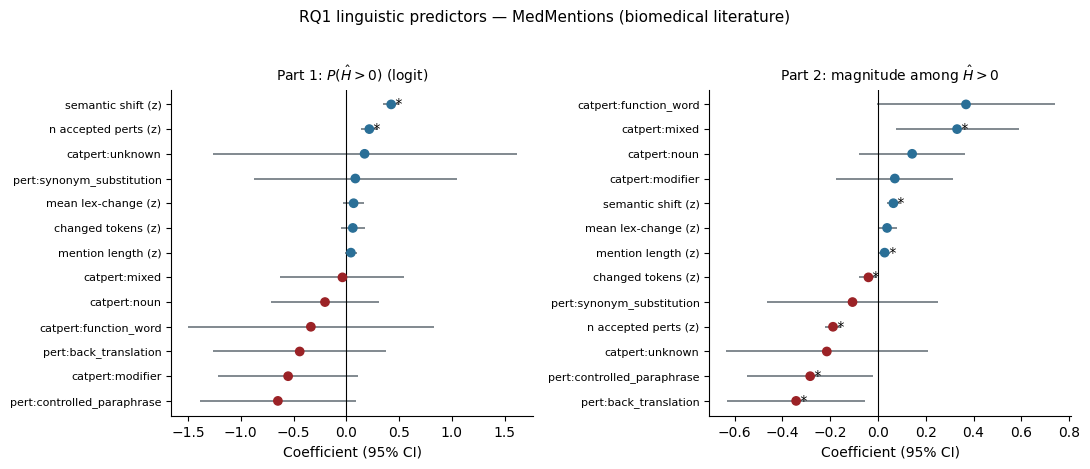

Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/figures/rq1_linguistic_predictors_coefs.png
Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/rq1_linguistic_predictors_summary.csv (30 rows)


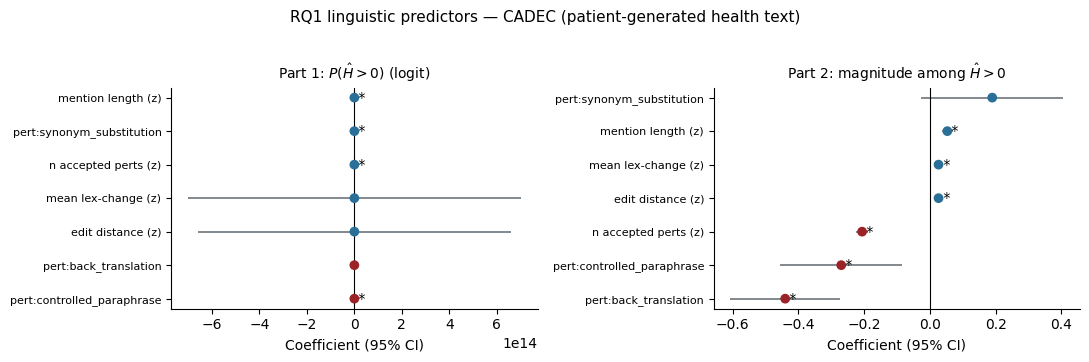

Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/figures/rq1_linguistic_predictors_coefs.png

VERDICT — which predictors significantly increase entropy?
CADEC = patient-generated health text (not clinical notes)

### MedMentions (biomedical literature)
  Binary method: GLM-Binomial + cluster-robust SE (cluster=instance_id); model_name as fixed effects (crossed RE not used — did not fit mixed logit)
  Magnitude method: OLS on logit(H) among H>0 + cluster-robust SE (cluster=instance_id); MixedLM did not converge / failed — fixed effects reported
  [raise P(entropy>0)]
    + semantic shift (z): coef=+0.425 [+0.350,+0.501] p=3.51e-28
    + n accepted perts (z): coef=+0.218 [+0.137,+0.300] p=1.49e-07
  [raise entropy magnitude | nonzero]
    + semantic shift (z): coef=+0.064 [+0.037,+0.092] p=6.11e-06
    + catpert:mixed: coef=+0.331 [+0.074,+0.588] p=0.0117
    + mention length (z): coef=+0.028 [+0.004,+0.051] p=0.0197
    − n accepted perts (z): co

In [5]:
# Export + plots + verdict
def _pretty_term(t: str) -> str:
    t = t.replace("_z", " (z)")
    t = t.replace("catshare_", "cat:")
    t = t.replace("share_", "pert:")
    t = t.replace("mean_lexical_change_magnitude", "mean lex-change")
    t = t.replace("mention_char_len", "mention length")
    t = t.replace("mean_changed_tokens_n", "changed tokens")
    t = t.replace("mean_semantic_shift", "semantic shift")
    t = t.replace("mean_edit_distance", "edit distance")
    t = t.replace("n_accepted_perts", "n accepted perts")
    return t


for ds_key, cfg in DATASETS.items():
    sub = df_summary_all[df_summary_all["dataset"] == ds_key].copy()
    out_csv = cfg["out_dir"] / f"rq1_linguistic_predictors_summary{ARM_SUFFIX}.csv"
    sub.to_csv(out_csv, index=False)
    print(f"Wrote {out_csv} ({len(sub)} rows)")

    # Coefficient plot: linguistic terms only, both parts
    ling = sub[sub["is_linguistic"]].copy()
    if len(ling) == 0:
        ling = sub[~sub["term"].str.startswith("C(model_name)") & (sub["term"] != "Intercept")]
    fig, axes = plt.subplots(1, 2, figsize=(11, max(3.5, 0.35 * ling.groupby("part").size().max())), sharex=False)
    for ax, part, title in zip(
        axes,
        ["logit_P_nonzero", "magnitude_nonzero"],
        [r"Part 1: $P(\hat H>0)$ (logit)", r"Part 2: magnitude among $\hat H>0$"],
    ):
        g = ling[ling["part"] == part].copy()
        if len(g) == 0:
            ax.set_axis_off()
            ax.set_title(title + " (no terms)")
            continue
        g = g.sort_values("coef")
        y = np.arange(len(g))
        colors = ["#2a6f97" if c > 0 else "#9b2226" for c in g["coef"]]
        ax.hlines(y, g["ci_low"], g["ci_high"], color="#6c757d", lw=1.2)
        ax.scatter(g["coef"], y, c=colors, s=36, zorder=3)
        ax.axvline(0, color="black", lw=0.8)
        ax.set_yticks(y)
        ax.set_yticklabels([_pretty_term(t) for t in g["term"]], fontsize=8)
        ax.set_xlabel("Coefficient (95% CI)")
        ax.set_title(title, fontsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        # star significant
        for yi, (_, r) in enumerate(g.iterrows()):
            if r["significant"]:
                ax.text(r["coef"], yi, " *", va="center", fontsize=10, color="black")

    fig.suptitle(
        f"RQ1 linguistic predictors — {cfg['label']}",
        fontsize=11,
        y=1.02,
    )
    fig.tight_layout()
    fig_path = cfg["fig_dir"] / f"rq1_linguistic_predictors_coefs{ARM_SUFFIX}.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Wrote {fig_path}")

# Cross-dataset verdict
print("\n" + "=" * 78)
print("VERDICT — which predictors significantly increase entropy?")
print("CADEC = patient-generated health text (not clinical notes)")
print("=" * 78)

def _sig_linguistic(ds, part, direction="increase"):
    sub = df_summary_all[
        (df_summary_all["dataset"] == ds)
        & (df_summary_all["part"] == part)
        & (df_summary_all["is_linguistic"])
        & (df_summary_all["significant"])
    ]
    if direction == "increase":
        sub = sub[sub["coef"] > 0]
    else:
        sub = sub[sub["coef"] < 0]
    return sub.sort_values("pvalue")

for ds_key, cfg in DATASETS.items():
    print(f"\n### {cfg['label']}")
    fr = FIT_RESULTS[ds_key]
    print(f"  Binary method: {fr['logit'].get('method')}")
    print(f"  Magnitude method: {fr['magnitude'].get('method')}")
    for part, desc in [
        ("logit_P_nonzero", "raise P(entropy>0)"),
        ("magnitude_nonzero", "raise entropy magnitude | nonzero"),
    ]:
        up = _sig_linguistic(ds_key, part, "increase")
        down = _sig_linguistic(ds_key, part, "decrease")
        print(f"  [{desc}]")
        if len(up):
            for _, r in up.iterrows():
                print(
                    f"    + {_pretty_term(r['term'])}: coef={r['coef']:+.3f} "
                    f"[{r['ci_low']:+.3f},{r['ci_high']:+.3f}] p={r['pvalue']:.3g}"
                )
        else:
            print("    (no significant positive linguistic effects)")
        if len(down):
            for _, r in down.iterrows():
                print(
                    f"    − {_pretty_term(r['term'])}: coef={r['coef']:+.3f} "
                    f"[{r['ci_low']:+.3f},{r['ci_high']:+.3f}] p={r['pvalue']:.3g}"
                )

# Consistency across datasets for shared predictor stems
print("\n### Cross-dataset consistency (shared linguistic stems)")
def _stem(t):
    t = t.replace("_z", "")
    for p in ["share_", "catshare_"]:
        if t.startswith(p):
            return t
    return t

if len(DATASETS) < 2:
    print(f"  cross-dataset agreement SKIPPED: only {sorted(DATASETS)} was run."
          " An empty other side is not disagreement.")
mm_sig = {
    (_stem(r.term), r.part, np.sign(r.coef))
    for _, r in df_summary_all[
        (df_summary_all.dataset == "MedMentions") & df_summary_all.is_linguistic & df_summary_all.significant
    ].iterrows()
}
cad_sig = {
    (_stem(r.term), r.part, np.sign(r.coef))
    for _, r in df_summary_all[
        (df_summary_all.dataset == "CADEC") & df_summary_all.is_linguistic & df_summary_all.significant
    ].iterrows()
}
shared_stems = {s[0] for s in mm_sig} & {s[0] for s in cad_sig}
if not shared_stems:
    # compare by family
    print("  No identical significant term stems in both datasets.")
for stem in sorted(shared_stems):
    mm_dirs = { (p, sgn) for (s, p, sgn) in mm_sig if s == stem }
    cad_dirs = { (p, sgn) for (s, p, sgn) in cad_sig if s == stem }
    agree = mm_dirs & cad_dirs
    print(f"  {stem}: MedMentions={mm_dirs} | CADEC={cad_dirs} | agree={bool(agree)}")

# Lexical change specifically
print("\n### Focus: lexical_change_magnitude")
for ds_key in ("MedMentions", "CADEC"):
    sub = df_summary_all[
        (df_summary_all.dataset == ds_key)
        & df_summary_all.term.str.contains("lexical_change")
    ]
    for _, r in sub.iterrows():
        print(
            f"  {ds_key:12s} {r['part']:20s} coef={r['coef']:+.3f} "
            f"p={r['pvalue']:.3g} sig={r['significant']}"
        )


In [ ]:
# RQ1 manuscript export: collinearity diagnostics + full coefficient tables.
# Added 2026-09-14 after an ALIASED PREDICTOR (lexical_change_magnitude was a literal copy of
# g5_edit_distance) made the logit design rank-deficient, the fit raise Singular matrix, and a
# broad `except Exception` turn that into an empty coefficient table that the verdict block
# then printed as "no significant positive linguistic effects" -- a false null result.
# Nothing here is allowed to report a part as empty when the part actually failed.
from statsmodels.stats.outliers_influence import variance_inflation_factor

RQ1_DOC = PROJECT_ROOT / "docs" / f"RQ1_CADEC_results{ARM_SUFFIX}.md"
_PARTS = [("logit_P_nonzero", "logit", "Part 1 — logit, P(H > 0)"),
          ("magnitude_nonzero", "magnitude", "Part 2 — magnitude of H given H > 0")]


def _diagnostics(res):
    """Condition number + VIF on the EXACT design the fit used (model.exog)."""
    m = res.get("model")
    if m is None:
        return None
    X = np.asarray(m.model.exog, dtype=float)
    names = list(m.model.exog_names)
    rank = int(np.linalg.matrix_rank(X))
    norms = np.linalg.norm(X, axis=0)
    norms[norms < 1e-12] = 1.0
    Xs = X / norms                       # Belsley column-scaling: cond is otherwise unitful
    out = {"n": int(X.shape[0]), "k": int(X.shape[1]), "rank": rank,
           "rank_deficient": rank < X.shape[1],
           "cond_raw": float(np.linalg.cond(X)),
           "cond_scaled": float(np.linalg.cond(Xs)), "vif": []}
    for j, nm in enumerate(names):
        if nm == "Intercept":
            continue
        try:
            v = float(variance_inflation_factor(X, j))
        except Exception as exc:          # reported as a failure, never as a blank
            v = float("nan")
            out.setdefault("vif_errors", []).append(f"{nm}: {exc}")
        out["vif"].append((nm, v))
    return out


def _fmt(x, nd=3):
    return "n/a" if x is None or (isinstance(x, float) and not np.isfinite(x)) else f"{x:.{nd}f}"


_L = []
for _ds_key in DATASETS:
    _fr = FIT_RESULTS[_ds_key]
    _d = _fr["data"]
    _L += [f"# RQ1 — {DATASETS[_ds_key]['label']}", "",
           "Hurdle model of normalised semantic entropy. Part 1 models whether entropy is "
           "non-zero at all; part 2 models its magnitude among the non-zero rows. Produced by "
           "`notebooks/05_analysis/RQ1_linguistic_predictors_hurdle.ipynb`.", ""]
    _ent_col = DATASETS[_ds_key]["entropy_col"]
    _L += [f"Entropy column: `{_ent_col}` (PRIMARY, de-duplicated denominator). Row set "
           f"filtered by `{DATASETS[_ds_key]['retained_col']}`. The raw-m arm "
           f"(`{DATASETS[_ds_key]['entropy_col_raw']}`) is the labelled sensitivity analysis "
           f"and is not reported here.", ""]
    _n_nz = int((_d["nonzero"] == 1).sum())
    _all_shares = sorted(c for c in _d.columns if c.startswith("share_"))
    _dropped_share = _all_shares[-1] if len(_all_shares) >= 2 else "none"
    _L += ["## Sample and the zero-inflation the hurdle is modelling", "",
           f"- Rows entering the model: **{len(_d):,}** "
           f"({_d['instance_id'].nunique():,} instances x {_d['model_name'].nunique()} models)",
           f"- Zero-entropy rows: **{int((_d['nonzero'] == 0).sum()):,}** "
           f"(**{(_d['nonzero'] == 0).mean():.2%}**) -- this is what part 1 models",
           f"- Non-zero rows entering part 2: **{_n_nz:,}** "
           f"(**{(_d['nonzero'] == 1).mean():.2%}**)",
           f"- Predictors: {', '.join('`' + p + '`' for p in _fr['zpreds'])}",
           f"- Model fixed effects: `C(model_name)`, "
           f"{_d['model_name'].nunique()} levels, "
           f"reference = `{sorted(_d['model_name'].unique())[0]}`",
           f"- Perturbation shares are a simplex, so the LAST one alphabetically is dropped "
           f"as the reference: `{_dropped_share}`. Every `share_*` coefficient below is "
           f"therefore read against it, not against zero.", ""]

    _L += ["## Collinearity diagnostics", "",
           "Computed on `model.exog`, i.e. the design matrix the fit actually used, not a "
           "re-derivation. `cond_scaled` is the condition number after scaling each column to "
           "unit norm (Belsley); the raw value is reported too but is unitful and not "
           "comparable across designs. Conventional reading: scaled condition number above 30 "
           "is worth noting, above 100 is serious; VIF above 10 is the usual flag.", ""]
    for _part, _key, _title in _PARTS:
        _dg = _diagnostics(_fr[_key])
        _L.append(f"**{_title}**")
        _L.append("")
        if _dg is None:
            _err = _fr[_key].get("error") or _fr[_key].get("mixed_error") or "unknown"
            _L += [f"> **FIT FAILED — no diagnostics.** `{_err}`", ""]
            continue
        _L += [f"- n = {_dg['n']:,}, columns = {_dg['k']}, rank = {_dg['rank']}"
               + ("  **RANK DEFICIENT**" if _dg["rank_deficient"] else ""),
               f"- condition number, scaled = **{_dg['cond_scaled']:.1f}** "
               f"(raw {_dg['cond_raw']:.1f})", "",
               "| term | VIF |", "|---|---:|"]
        for _nm, _v in sorted(_dg["vif"], key=lambda t: (-t[1] if np.isfinite(t[1]) else 0)):
            _flag = "  **>10**" if np.isfinite(_v) and _v > 10 else ""
            _L.append(f"| `{_nm}` | {_fmt(_v, 2)}{_flag} |")
        _L.append("")
        if _dg.get("vif_errors"):
            _L += ["VIF could not be computed for: " + "; ".join(_dg["vif_errors"]), ""]

    _L += ["## Coefficients", "",
           "Every term, both parts, with 95% confidence intervals and p-values. Model fixed "
           "effects are included rather than suppressed: they are large here and a reader "
           "comparing linguistic effects needs to see what they are being compared against.", ""]
    for _part, _key, _title in _PARTS:
        _res = _fr[_key]
        _L.append(f"### {_title}")
        _L.append("")
        if _res.get("model") is None:
            _err = _res.get("error") or _res.get("mixed_error") or "unknown"
            _L += [f"> **THIS PART DID NOT FIT.** `{_err}`", "",
                   "> An absent table here means the model failed, NOT that no effects were "
                   "found. Do not report it as a null result.", ""]
            continue
        _n_part = len(_d) if _part == "logit_P_nonzero" else int((_d["nonzero"] == 1).sum())
        _L += [f"Method: {_res['method']}", "", f"n = {_n_part:,}", "",
               "| term | coef | 95% CI | p | sig |", "|---|---:|:---:|---:|:--:|"]
        _sub = df_summary_all[(df_summary_all["dataset"] == _ds_key)
                              & (df_summary_all["part"] == _part)]
        for _, _r in _sub.iterrows():
            _L.append(f"| `{_r['term']}` | {_r['coef']:+.4f} | "
                      f"[{_r['ci_low']:+.4f}, {_r['ci_high']:+.4f}] | "
                      f"{_r['pvalue']:.3g} | {'**yes**' if _r['significant'] else 'no'} |")
        _L.append("")
    _L += [f"Significance threshold alpha = {ALPHA}. No multiplicity correction is applied "
           f"within this table.", ""]

RQ1_DOC.write_text("\n".join(_L) + "\n", encoding="utf-8")
print(f"Wrote {RQ1_DOC}")
print("\n".join(_L[:4]))
